In [2]:
from measurments import Sim, map_unstructured_to_structured_3d_optimized
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

In [3]:
sim_sol = Sim("/u/jbiba/projects/turbulent-driving/driving128-mach0.5/")
sim_mix = Sim("/u/jbiba/projects/turbulent-driving/driving128-mach0.5-comp/")
sim_static = Sim("/u/jbiba/projects/turbulent-driving/driving128-mach0.5-staticmesh/")

Plots:

- velocity movie
- combined mach number
- density pdf for com vs sol vs stat fig4 fed2010
- velocity powerspectrum com vs sol vs static
- evolution of density odf for sol
- evolution vps for sol
- velocity picture side by side with vps
- volume weighetd correlation pdf mach number vs log dens
- evolution of ?

In [4]:
plt.rcParams.update({
    "text.usetex": False,
    "text.latex.preamble": r"""
        \usepackage{amsmath}
        \usepackage{bm}
        \usepackage{geometry}
    """,
    "font.family": "serif",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.linewidth": 1.5,       # Thicker border
    "xtick.major.width": 1.2,    # Thicker x ticks
    "ytick.major.width": 1.2,    # Thicker y ticks
    "xtick.labelsize": 14,       # Larger tick labels
    "ytick.labelsize": 14,
    "axes.labelsize": 16,        # Larger axis labels
    "axes.titlesize": 18,        # Larger title
    "lines.linewidth": 2.0
})

(<matplotlib.image.AxesImage at 0x14f3f980a710>,
 array([[2.93247273, 2.93259552, 2.9314017 , ..., 2.9254168 , 2.92661111,
         2.93164494],
        [2.93465486, 2.936446  , 2.93472589, ..., 2.9216448 , 2.92501366,
         2.93116054],
        [2.93411624, 2.9364621 , 2.94064576, ..., 2.92607622, 2.92667891,
         2.92764416],
        ...,
        [2.9157765 , 2.91775144, 2.92256078, ..., 2.9011112 , 2.91237619,
         2.92175789],
        [2.92558687, 2.92763463, 2.92591422, ..., 2.90890542, 2.92076721,
         2.92333603],
        [2.93003514, 2.92939554, 2.92466521, ..., 2.91106617, 2.92709064,
         2.92821765]], shape=(200, 200)))

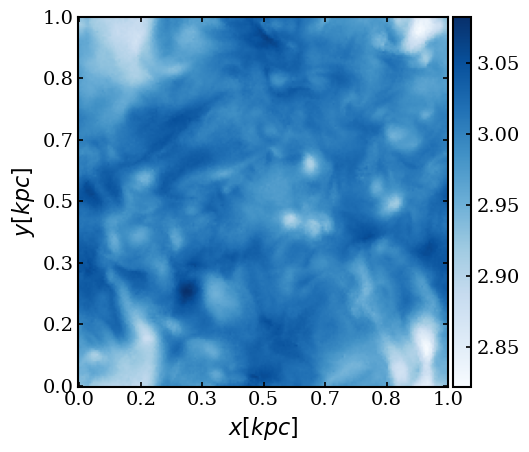

In [16]:
fig, ax = plt.subplots()
sim_sol.prop_image(200, "Density", fig, ax, cols=10, norm="log", cmap="Blues", grid=200)

(<matplotlib.image.AxesImage at 0x14f3e81e8550>,
 array([[2.95780112, 2.95476218, 2.9538005 , ..., 2.969047  , 2.96251683,
         2.96060972],
        [2.95821133, 2.9565433 , 2.95337135, ..., 2.96837687, 2.96478514,
         2.95960664],
        [2.95752723, 2.95711891, 2.95138359, ..., 2.96772348, 2.96488802,
         2.96068685],
        ...,
        [2.96305175, 2.96373837, 2.96403939, ..., 2.97855495, 2.97874671,
         2.97690503],
        [2.96066765, 2.96225359, 2.96084439, ..., 2.97674661, 2.97219078,
         2.97009922],
        [2.95866543, 2.95828921, 2.95857591, ..., 2.97567071, 2.96874534,
         2.96895485]], shape=(200, 200)))

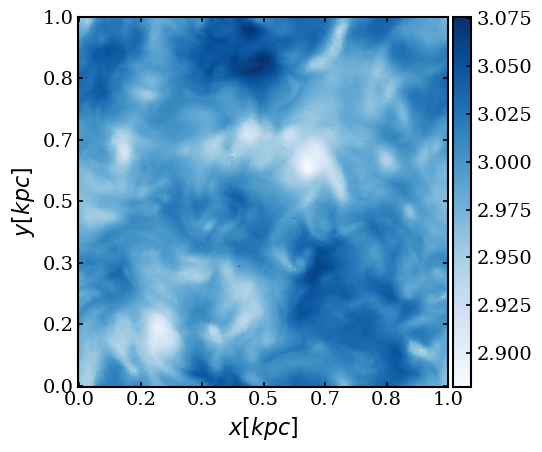

In [19]:
fig, ax = plt.subplots()
sim_mix.prop_image(300, "Density", fig, ax, cols=10, norm="log", cmap="Blues", grid=200)

  0%|          | 0/401 [00:00<?, ?it/s]

100%|██████████| 401/401 [03:51<00:00,  1.73it/s]


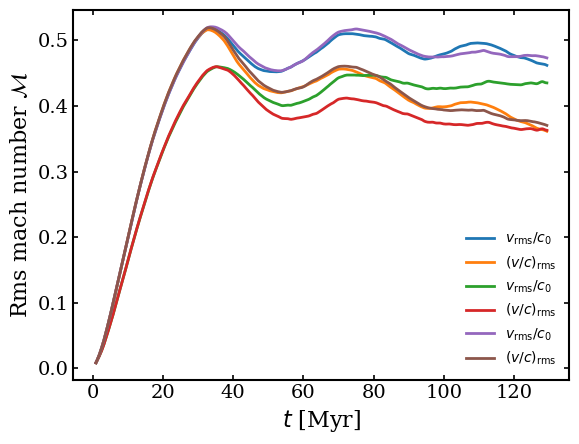

In [6]:
fig, ax = plt.subplots()
plots_sol, data_sol = sim_sol.mach_number_plot(fig, ax)
plots_mix, data_mix = sim_mix.mach_number_plot(fig, ax)
plots_static, data_static = sim_static.mach_number_plot(fig, ax)

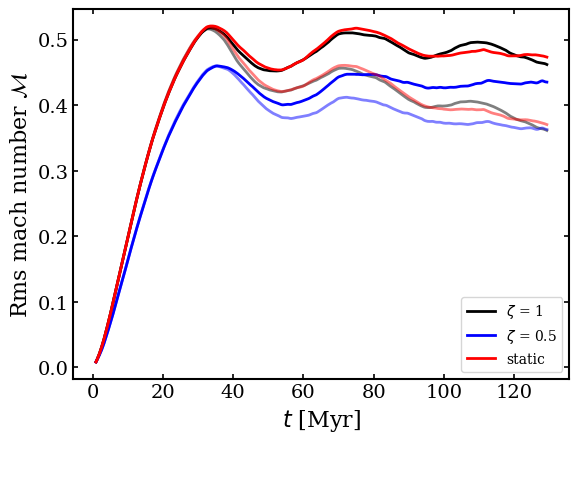

In [34]:
plots_sol[0][0].set_color("black")
plots_sol[0][0].set_label(r"$\zeta$ = 1")
plots_sol[1][0].set_color("black")
plots_sol[1][0].set_label("")
plots_sol[1][0].set_alpha(0.5)

plots_mix[0][0].set_color("blue")
plots_mix[0][0].set_label(r"$\zeta$ = 0.5")
plots_mix[1][0].set_color("blue")
plots_mix[1][0].set_label("")
plots_mix[1][0].set_alpha(0.5)

plots_static[0][0].set_color("red")
plots_static[0][0].set_label(r"static")
plots_static[1][0].set_color("red")
plots_static[1][0].set_label("")
plots_static[1][0].set_alpha(0.5)
ax.legend()
fig

In [35]:
fig.savefig("rms_comparison.pdf")

Text(0, 0.5, 'Driving force magnitude')

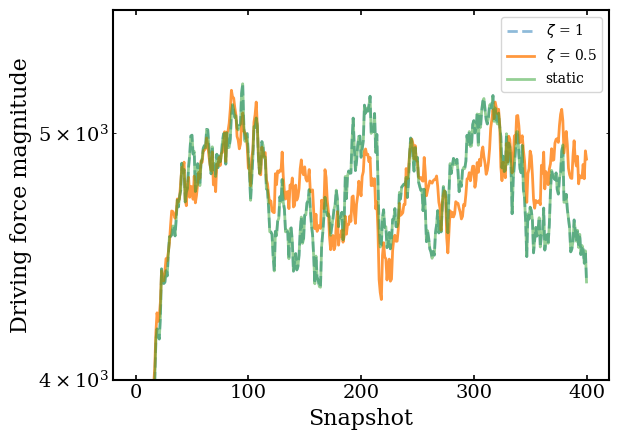

In [9]:
fig, ax = plt.subplots()
ax.plot(data_sol[:, 3], label=r"$\zeta$ = 1", linestyle="--", alpha=0.5)
ax.plot(data_mix[:, 3], label=r"$\zeta$ = 0.5", alpha=0.8)
ax.plot(data_static[:, 3], label="static", alpha=0.5)
ax.legend()
ax.set_yscale("log")
ax.set_ylim(4e3)
ax.set_xlabel("Snapshot")
ax.set_ylabel("Driving force magnitude")
# fig.savefig("driving_force_comparison.pdf")

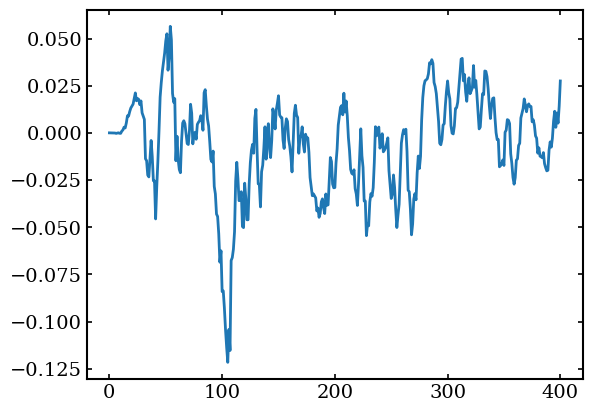

In [10]:
plt.plot(data_sol[:, 3] - data_static[:, 3])

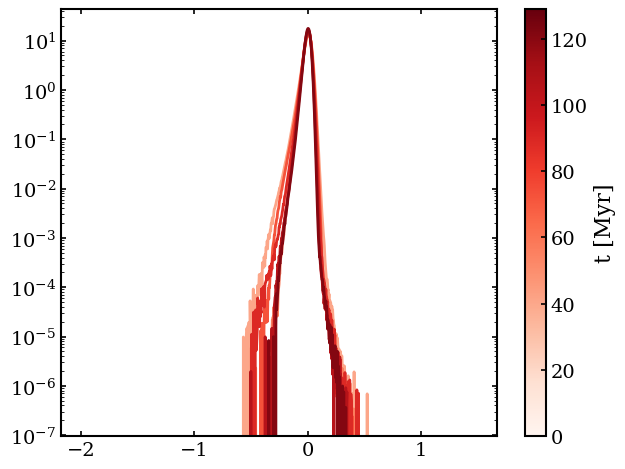

In [4]:
fig, ax = plt.subplots()
sim_sol.property_pdf_evolution("Density", fig, ax, start=100, stop=400, num_evol=6, avg=50)

In [11]:
ax.set_xlim(-0.5, 0.2)
ax.set_ylim(1e-5)
ax.set_xlabel(r"$\log(\rho/\langle\rho\rangle)$")
ax.set_ylabel("Volume weighted PDF")
fig.tight_layout()
fig.savefig("density_pdf_evolution_sol.pdf", bbox_inches='tight')

Text(0, 0.5, 'Volume weighted PDF')

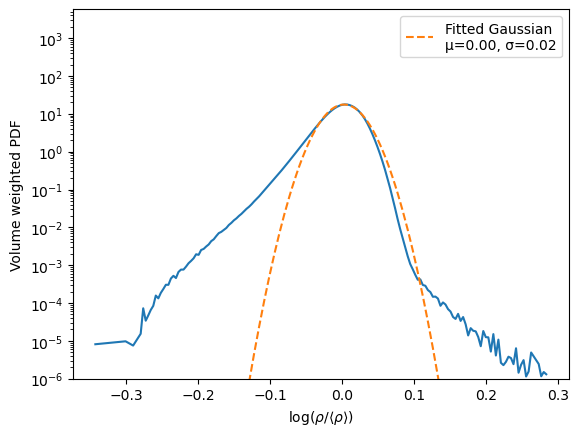

In [ ]:
fig, ax = plt.subplots()

ax.set_xlabel(r"$\log(\rho/\langle\rho\rangle)$")
ax.set_ylabel("Volume weighted PDF")

Text(0, 0.5, 'Volume weighted PDF')

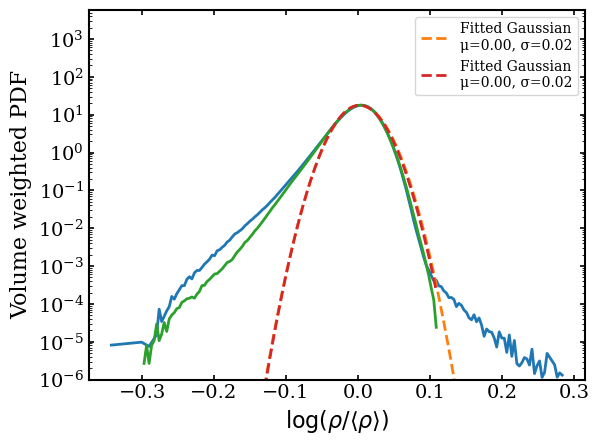

In [19]:
fig, ax = plt.subplots()
line_sol, gauss_sol = sim_sol.property_pdf("Density", 350, fig, ax, avg=100)
line_mix, gauss_mix = sim_static.property_pdf("Density", 350, fig, ax, avg=100)
ax.set_xlabel(r"$\log(\rho/\langle\rho\rangle)$")
ax.set_ylabel("Volume weighted PDF")

In [20]:
gauss_sol[0].set_alpha(0.5)
gauss_mix[0].set_alpha(0.5)
gauss_sol[0].set_color("orange")
gauss_mix[0].set_color("green")
line_sol[0].set_color("orange")
line_mix[0].set_color("green")
line_sol[0].set_label(r"$\zeta = 1$")
line_mix[0].set_label("static")
ax.legend()
fig.savefig("density_pdf_sol_static_comparison_snap350-average.pdf", bbox_inches="tight")

In [6]:
sim = Sim("/u/jbiba/projects/turbulent-driving/driving128-mach10")

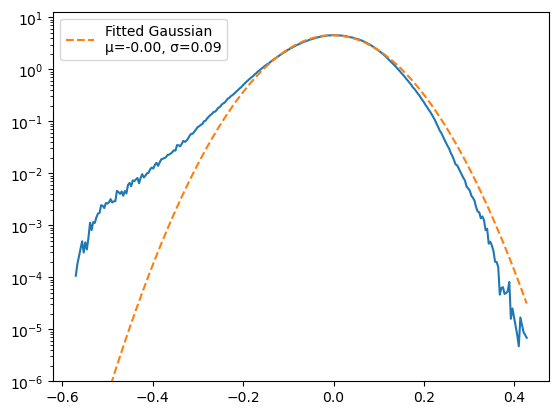

In [9]:
fig, ax = plt.subplots()
sim.property_pdf("Density", 70, fig, ax, avg=5)

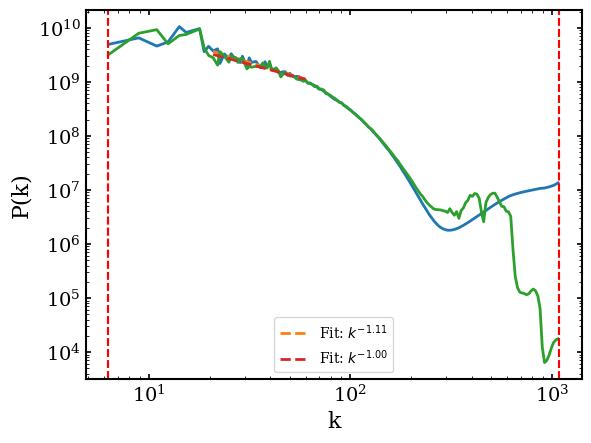

In [4]:
fig, ax = plt.subplots()
sol_line, sol_fit, sol_data = sim_sol.velocity_power_spectrum(350, fig, ax, grid=200, avg=10)
static_line, static_fit, static_data = sim_static.velocity_power_spectrum(350, fig, ax, grid=200, avg=10)

In [ ]:
sol_line[0].set_color("orange")
sol_fit[0].set_color("orange")
sol_line[0].set_label(r"$\zeta = 1$")
sol_fit[0].set_alpha(1)

static_line[0].set_color("purple")
static_line[0].set_label("static")
static_fit[0].set_color("purple")
static_fit[0].set_alpha(1)
ax.legend()
fig.savefig("vps_sol_static_comparision_snap350-average10.pdf")

In [ ]:
fig, ax = plt.subplots()
sim_sol.velocity_power_spectrum(350, fig, ax, grid=200, avg=1)

Text(0.02, 0.5, 'P(k)')

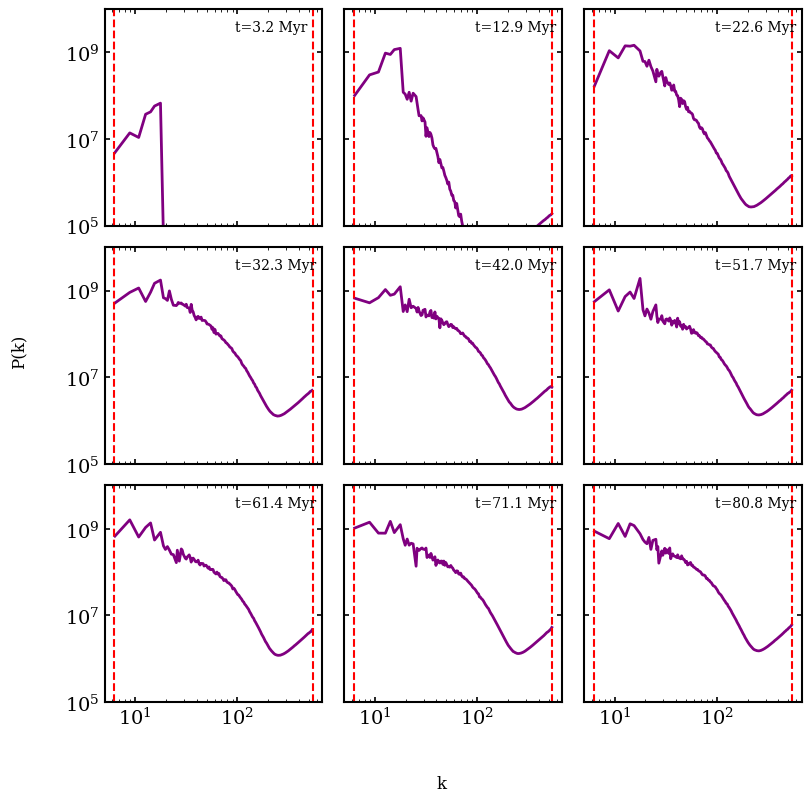

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(9, 9),
                         sharex=True, sharey=True,
                         gridspec_kw={'wspace': 0.1, 'hspace': 0.1})

# Flatten axes for easy iteration
axes = axes.flatten()

snaps = np.array([10, 40, 70, 100, 130, 160, 190, 220, 250])

times = snaps*sim_sol.time_bet_snaps

for i, ax in enumerate(axes):
    sol_line, sol_fit, sol_data = sim_sol.velocity_power_spectrum(snaps[i], fig, ax, grid=100, avg=5)
    ax.legend().remove()
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_ylim(1e5, 1e10)
    sol_line[0].set_color("purple")
    sol_fit[0].remove()

# Optional: Add titles or time labels inside plots
for i, ax in enumerate(axes):
    ax.text(0.6, 0.95, f"t={times[i]:.1f} Myr", transform=ax.transAxes, fontsize=10, ha='left', va='top')


fig.supxlabel('k')
fig.supylabel('P(k)')

In [17]:
fig.savefig("vps_sol_evolution.pdf")

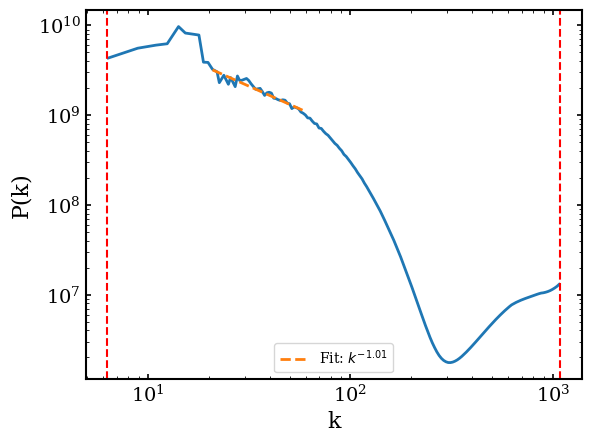

In [18]:
fig, ax = plt.subplots()
sol_line, sol_fit, sol_data = sim_sol.velocity_power_spectrum(350, fig, ax, grid=200, avg=200)

In [19]:
sol_line[0].set_color("purple")
sol_fit[0].set_color("black")
sol_line[0].set_label(r"$\zeta = 1$")
sol_fit[0].set_alpha(1)
ax.legend()
fig.savefig("vps_sol_averaged.pdf")

In [27]:
energy_in_list = np.zeros(len(sim_sol.snaps))

for i in range(len(sim_sol.snaps)):
    data = sim_sol.load(i, ["Density", "Acceleration", "Masses", "Velocities"])
    volume = data["Masses"]/data["Density"]
    force = data["Masses"][:, np.newaxis]*data["Acceleration"]
    f_dot_v = np.sum(force * data["Velocities"], axis=1)
    energy_in_list[i] = np.sum(data["Density"] * f_dot_v * volume)

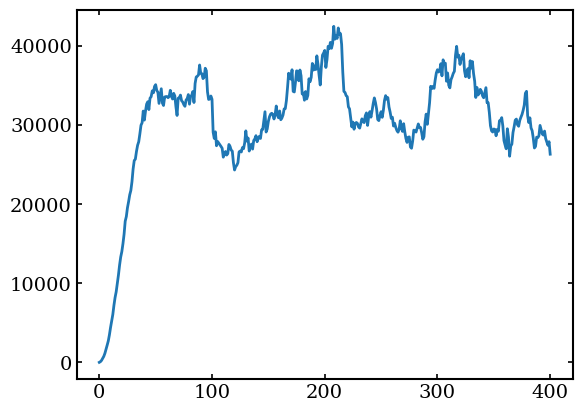

In [29]:
plt.plot(energy_in_list)

In [7]:
density = sim_sol.load(300, "Density")
masses = sim_sol.load(300, "Masses")

In [8]:
volumes = masses/density

In [10]:
mean_dens = np.sum(volumes * density)
s = np.log(density/mean_dens)

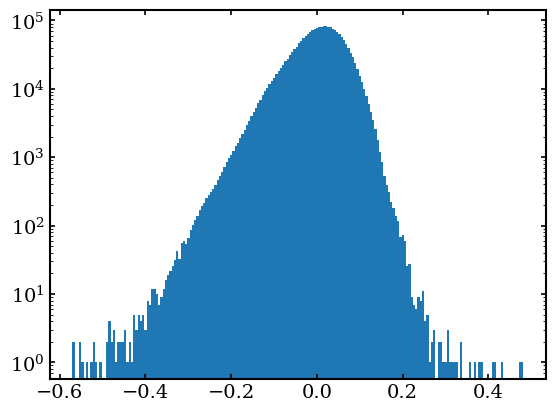

In [24]:
plt.hist(s, bins=200)
plt.yscale("log")
plt.show()

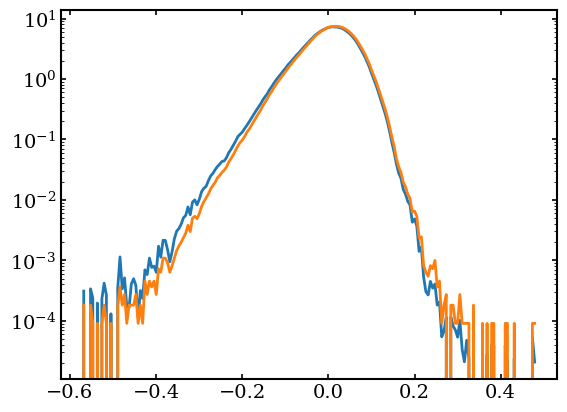

In [29]:
histo, bin_edges = np.histogram(s, bins=200, weights=volumes, density=True)
histo2, bin_edges2 = np.histogram(s, bins=200, density=True)

bin_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])
bin_centers2 = 0.5*(bin_edges2[1:] + bin_edges2[:-1])

plt.plot(bin_centers, histo)
plt.plot(bin_centers2, histo2)

plt.yscale("log")
plt.show()

In [28]:
print(0.5*(bin_edges[1:] + bin_edges[:-1]))

[-5.67945387e-01 -5.62684626e-01 -5.57423865e-01 -5.52163104e-01
 -5.46902343e-01 -5.41641582e-01 -5.36380821e-01 -5.31120061e-01
 -5.25859300e-01 -5.20598539e-01 -5.15337778e-01 -5.10077017e-01
 -5.04816256e-01 -4.99555495e-01 -4.94294734e-01 -4.89033973e-01
 -4.83773212e-01 -4.78512451e-01 -4.73251690e-01 -4.67990930e-01
 -4.62730169e-01 -4.57469408e-01 -4.52208647e-01 -4.46947886e-01
 -4.41687125e-01 -4.36426364e-01 -4.31165603e-01 -4.25904842e-01
 -4.20644081e-01 -4.15383320e-01 -4.10122559e-01 -4.04861799e-01
 -3.99601038e-01 -3.94340277e-01 -3.89079516e-01 -3.83818755e-01
 -3.78557994e-01 -3.73297233e-01 -3.68036472e-01 -3.62775711e-01
 -3.57514950e-01 -3.52254189e-01 -3.46993429e-01 -3.41732668e-01
 -3.36471907e-01 -3.31211146e-01 -3.25950385e-01 -3.20689624e-01
 -3.15428863e-01 -3.10168102e-01 -3.04907341e-01 -2.99646580e-01
 -2.94385819e-01 -2.89125058e-01 -2.83864298e-01 -2.78603537e-01
 -2.73342776e-01 -2.68082015e-01 -2.62821254e-01 -2.57560493e-01
 -2.52299732e-01 -2.47038